<a href="https://colab.research.google.com/github/rmilde/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Assignment%201/Econ_5200_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Data Construction
student_basket = [
    {'Item': 'Tuition', 'Price_2016': 45000, 'Price_2024': 58000},
    {'Item': 'Rent (1 Bed)', 'Price_2016': 1200, 'Price_2024': 1800},
    {'Item': 'Chipotle Burrito', 'Price_2016': 7.50, 'Price_2024': 11.50},
    {'Item': 'TV', 'Price_2016': 10 , 'Price_2024' : 15}
]

In [24]:
# Define the "Machine" (Function)
def calculate_inflation(base, current):
    return ((current - base) / base) * 100

# Run the Loop
for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2024'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

Tuition: 28.89% Inflation
Rent (1 Bed): 50.00% Inflation
Chipotle Burrito: 53.33% Inflation
TV: 50.00% Inflation


In [25]:
!pip install fredapi
from fredapi import Fred
fred = Fred(api_key='my api key')

# Fetch Series
official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB')
rent = fred.get_series('CUSR0000SEHA')
food_away = fred.get_series('CUSR0000SEFV')
tv = fred.get_series('CUSR0000SERA02')

In [26]:
import pandas as pd

#create dataframe for ease
df = pd.DataFrame({
    'official_CPI': official_cpi,
    'tuition': tuition,
    'rent': rent,
    'food_away': food_away,
    'tv': tv
})

In [27]:
df

,official_CPI,tuition,rent,food_away,tv
1947-01-01,21.480,NaN,NaN,NaN,NaN
1947-02-01,21.620,NaN,NaN,NaN,NaN
1947-03-01,22.000,NaN,NaN,NaN,NaN
1947-04-01,22.000,NaN,NaN,NaN,NaN
1947-05-01,21.950,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2025-08-01,323.364,895.305,437.462,384.909,592.604
2025-09-01,324.368,897.302,438.322,385.451,593.928
2025-10-01,NaN,NaN,NaN,NaN,NaN
2025-11-01,325.031,902.001,438.875,387.202,599.226


In [30]:
# create re-idexing function
def re_index(data, new_index_year):
  value_at_start_date = data.loc[new_index_year]

  normalized_data = []

  for point in data:
    value_current = point
    value_index = (value_current / value_at_start_date) * 100
    normalized_data.append(value_index)

  return normalized_data

In [32]:
# apply re-indexing function
df_normalized = df.copy()

for col in df.columns:
  df_normalized[col] = re_index(df[col], '2016-01-01')

In [33]:
df_normalized

,official_CPI,tuition,rent,food_away,tv
1947-01-01,9.038426,NaN,NaN,NaN,NaN
1947-02-01,9.097336,NaN,NaN,NaN,NaN
1947-03-01,9.257233,NaN,NaN,NaN,NaN
1947-04-01,9.257233,NaN,NaN,NaN,NaN
1947-05-01,9.236194,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2025-08-01,136.066181,127.901262,149.969832,148.065841,138.608498
2025-09-01,136.488647,128.186549,150.264655,148.274337,138.918178
2025-10-01,NaN,NaN,NaN,NaN,NaN
2025-11-01,136.767627,128.857838,150.454234,148.947907,140.157366


Text(0, 0.5, 'Prices Indexed Relative to 2016')

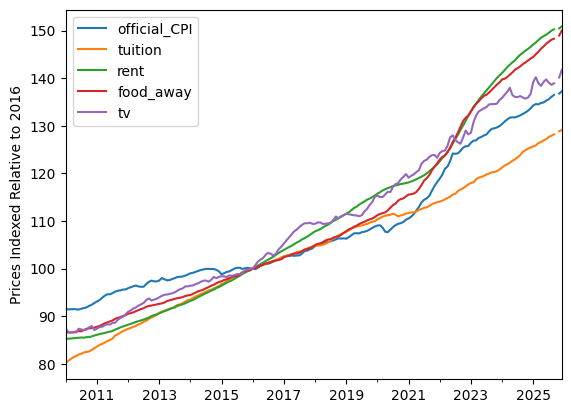

In [34]:
import matplotlib.pyplot as plt

# graph
df_normalized.loc['2010-01-01':].plot()
plt.ylabel('Prices Indexed Relative to 2016')

In [35]:
#create weight dictionary
weight_dict = {'tuition': 0.5,
    'rent': 0.3,
    'food_away': 0.1,
    'tv': 0.1}

In [36]:
df_normalized['Student_SPI'] = 0

#apply weight
for item, weight in weight_dict.items():
  df_normalized['Student_SPI'] += df_normalized[item] * weight

In [37]:
df_normalized

,official_CPI,tuition,rent,food_away,tv,Student_SPI
1947-01-01,9.038426,NaN,NaN,NaN,NaN,NaN
1947-02-01,9.097336,NaN,NaN,NaN,NaN,NaN
1947-03-01,9.257233,NaN,NaN,NaN,NaN,NaN
1947-04-01,9.257233,NaN,NaN,NaN,NaN,NaN
1947-05-01,9.236194,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-08-01,136.066181,127.901262,149.969832,148.065841,138.608498,137.609015
2025-09-01,136.488647,128.186549,150.264655,148.274337,138.918178,137.891923
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,136.767627,128.857838,150.454234,148.947907,140.157366,138.475716


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


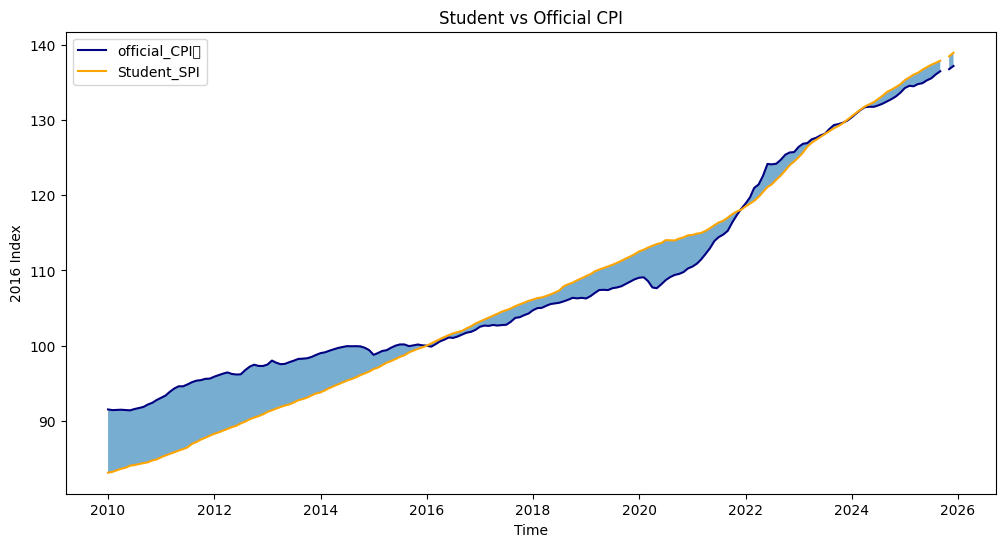

In [40]:
df_subset = df_normalized.loc['2010-01-01':]

#plot
plt.figure(figsize=(12, 6))
plt.plot(df_subset.index, df_subset['official_CPI'], label='official_CPI	', color='navy')
plt.plot(df_subset.index, df_subset['Student_SPI'], label='Student_SPI', color='orange')
plt.fill_between(df_subset.index, df_subset['official_CPI'], df_subset['Student_SPI'], alpha=0.6)
plt.title('Student vs Official CPI')
plt.xlabel('Time')
plt.ylabel('2016 Index')
plt.legend()
plt.show()

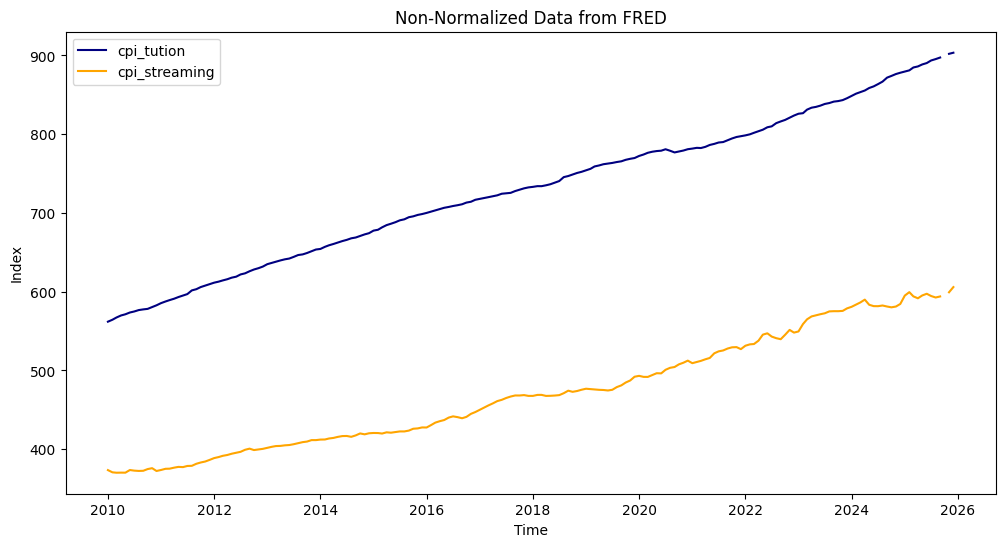

In [42]:
df_subset = df.loc['2010-01-01':]

#plot the 'bad' graph
plt.figure(figsize=(12, 6))
plt.plot(df_subset.index, df_subset['tuition'], label='cpi_tution', color='navy')
plt.plot(df_subset.index, df_subset['tv'], label='cpi_streaming', color='orange')
plt.title('Non-Normalized Data from FRED')
plt.xlabel('Time')
plt.ylabel('Index')
plt.legend()
plt.show()

Comparing raw indices with different base years is misleading. Since the different categories have different base years that means the indexes are in reference to different time periods and thus not directly comparabale.  A 200% increase since 2002 is very different than a 200% increase since 1982, becuase the intial price in those years is very different. However, when they are presented on the same graph with the same axis this is not clear to the veiwer and may lead them to incorrectly interpert the resulting graph. Therfore, we must normalize the data so that the base years are the same and then we can compare the different category indexes and plot them toegther in the same graph.

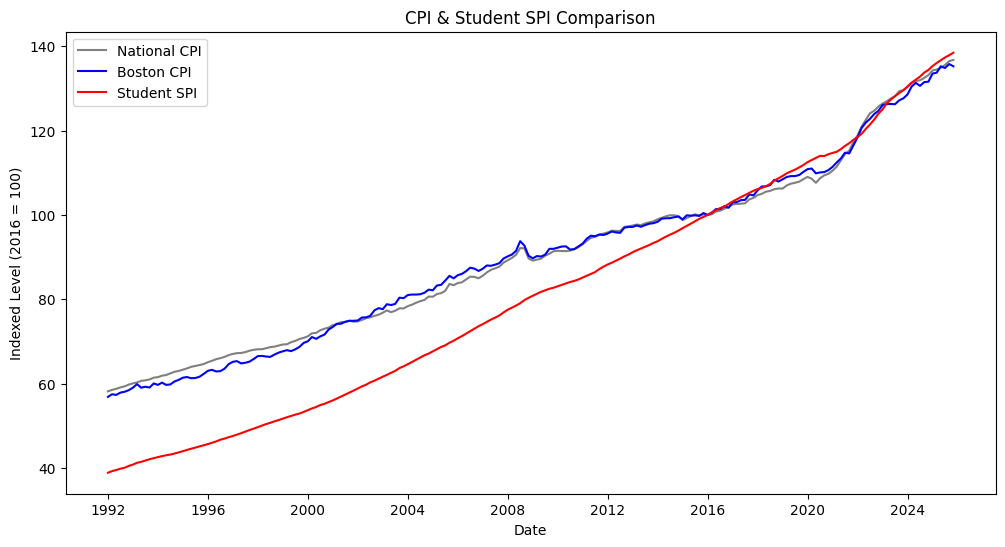

In [22]:
# ——————————————————
# 1) Fetch Boston CPI from FRED
# ——————————————————

fred = Fred(api_key="28cfb1398495ff14d9196d406f870392")

# Fetch series
boston_cpi = fred.get_series("CUURA103SA0")  # Boston CPI (monthly) :contentReference[oaicite:1]{index=1}

# Convert to DataFrame
df_boston = pd.DataFrame(boston_cpi, columns=["Boston_CPI"])

# ——————————————————
# 2) Re-index so Jan 2016 = 100
# ——————————————————

# Ensure datetime index
df_boston.index = pd.to_datetime(df_boston.index)

# Extract value at Jan 2016
base_value = df_boston.loc["2016-01-01", "Boston_CPI"]

# Normalize
df_boston["Boston_CPI_Indexed"] = df_boston["Boston_CPI"] / base_value * 100

# ——————————————————
# 3) Align with your df (national CPI & student SPI)
# ——————————————————

# Make a combined DataFrame including all three series
df_plot = pd.DataFrame({
    "National_CPI": df_normalized["official_CPI"],        # your national CPI
    "Boston_CPI": df_boston["Boston_CPI_Indexed"],
    "Student_SPI": df_normalized["Student_SPI"]
})

# Optionally drop missing values to align dates
df_plot = df_plot.dropna()

# ——————————————————
# 4) Plot with Matplotlib
# ——————————————————

plt.figure(figsize=(12, 6))

plt.plot(df_plot.index, df_plot["National_CPI"], label="National CPI", color="grey")
plt.plot(df_plot.index, df_plot["Boston_CPI"], label="Boston CPI", color="blue")
plt.plot(df_plot.index, df_plot["Student_SPI"], label="Student SPI", color="red")

plt.title("CPI & Student SPI Comparison")
plt.xlabel("Date")
plt.ylabel("Indexed Level (2016 = 100)")
plt.legend()

plt.show()